In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

In [2]:
def load(idx='wig20',start_date='2010-01-01', end_date=datetime.today().strftime('%Y-%m-%d')):
    url = f'https://stooq.pl/q/d/l/?s={idx}&i=d'
    df = pd.read_csv(url)
    df.rename({'Data':'Date','Otwarcie':'Open','Najwyzszy':'High','Najnizszy':'Low','Zamkniecie':'Close','Wolumen':'Volume'}, axis=1, inplace=True)
    df.set_index('Date', inplace=True)
    df.index = pd.to_datetime(df.index)
    df = df.loc[start_date:end_date]
    df['Returns'] = np.log(df['Close'] / df['Close'].shift(1))
    df.dropna(inplace=True)
    return df


In [3]:
def explore():
    df = load()

    # returns, close, volatility
    monthly_returns = df['Returns'].resample('M').sum()

    fig, (ax1, ax2, ax3, ax4) = plt.subplots(
        4, 1,
        figsize=(12, 9),
        sharex=True
    )

    ax1.plot(df.index, df['Close'], color='black', linewidth=1)
    ax1.set_title('Daily Close Price', fontsize=12)
    ax1.set_ylabel('Close')

    ax2.plot(df.index, df['Returns'], color='black', linewidth=0.7)
    ax2.set_title('Daily Log Returns', fontsize=12)
    ax2.set_ylabel('Return')
    ax2.axhline(0, color='red', linestyle='--', linewidth=0.7)

    ax3.plot(monthly_returns.index, monthly_returns, color='black', linewidth=1)
    ax3.set_title('Monthly Log Returns', fontsize=12)
    ax3.set_ylabel('Return')
    ax3.axhline(0, color='red', linestyle='--', linewidth=0.7)

    ax4.plot(df['Returns'].rolling(window=30).std(), color='black', linewidth=.9)
    ax4.set_title('30-Day Rolling Volatility')
    ax4.set_ylabel('Return Std')

    ax2.xaxis.set_major_locator(mdates.YearLocator(2))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.tight_layout()
    plt.show()

    # ACF
    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(15, 6),
        sharex=True
    )

    plot_acf(df['Returns'], lags=30, ax=ax1)
    ax1.set_title('ACF Daily Log Returns')

    plot_acf(df['Returns']**2, lags=30, ax=ax2)
    ax2.set_title('ACF Squared Daily Log Returns')

    plt.tight_layout()
    plt.show()

    # Dist
    skew = df['Returns'].skew()
    kurt = df['Returns'].kurtosis()

    fig, (ax1, ax2) = plt.subplots(
        1,2,
        figsize=(15, 5)
    )
    ax1.hist(df['Returns'], bins=100, density=True, alpha=0.5)
    sns.kdeplot(df['Returns'], color='red', linewidth=2, ax=ax1)

    ax1.set_title('Distribution of Daily Log Returns')
    ax1.text(
        0.02, 0.95,
        f'Skewness: {skew:.3f}\nKurtosis: {kurt:.3f}',
        transform=ax1.transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle='round', alpha=0.3)
    )

    # Quantiles
    stats.probplot(df['Returns'], dist='norm', plot=ax2)
    ax2.set_title('QQ Plot')

    plt.tight_layout()
    plt.show()

    # Empirical vs parametric VaR
    window = 250 
    df['VaR_95_q'] = df['Returns'].rolling(window).quantile(0.05)

    rolling_mean = df['Returns'].rolling(window).mean()
    rolling_std = df['Returns'].rolling(window).std()
    z_5 = stats.norm.ppf(0.05)
    df['VaR_95_param'] = rolling_mean + z_5 * rolling_std

    plt.figure(figsize=(15,10))
    plt.plot(df.index, df['Returns'], label='Daily log return', alpha=0.6, color='black')
    plt.plot(df.index, df['VaR_95_q'], label='Rolling 95% VaR (5% quantile)', color='red')
    plt.plot(df.index, df['VaR_95_param'], label='Rolling 95% VaR (parametric normal)', color='blue', linestyle='--')
    plt.title('Daily Log Returns vs VaR')
    plt.xlabel('Date')
    plt.ylabel('Return')
    plt.legend()
    plt.show()


In [4]:
df = load()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4052 entries, 2010-01-05 to 2026-03-20
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Open     4052 non-null   float64
 1   High     4052 non-null   float64
 2   Low      4052 non-null   float64
 3   Close    4052 non-null   float64
 4   Volume   4052 non-null   float64
 5   Returns  4052 non-null   float64
dtypes: float64(6)
memory usage: 221.6 KB


,Open,High,Low,Close,Volume,Returns
count,4052.000000,4052.000000,4052.000000,4052.000000,4.052000e+03,4052.000000
mean,2268.160735,2284.328833,2249.712937,2267.322270,2.591278e+07,0.000070
std,339.273704,339.499065,338.599638,339.604945,1.596111e+07,0.013201
min,1334.370000,1356.010000,1248.770000,1305.730000,5.343204e+06,-0.142456
25%,2079.905000,2098.930000,2057.070000,2078.940000,1.755219e+07,-0.007062
50%,2299.270000,2314.355000,2280.600000,2298.615000,2.231026e+07,0.000144
75%,2441.045000,2455.545000,2426.065000,2441.992500,2.891652e+07,0.007346
max,3474.640000,3485.600000,3435.810000,3480.470000,2.447131e+08,0.080995


C:\Users\barto\AppData\Local\Temp\ipykernel_19636\1908360955.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_returns = df['Returns'].resample('M').sum()


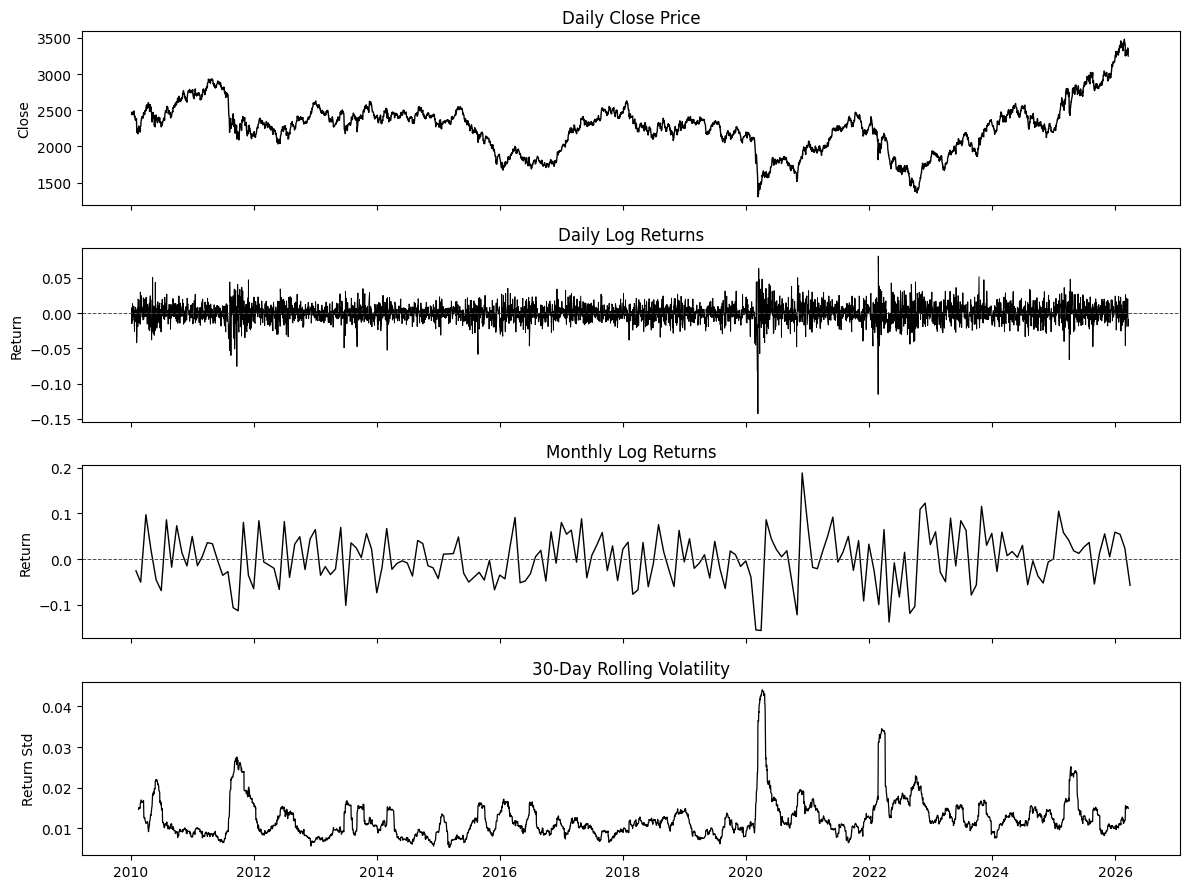

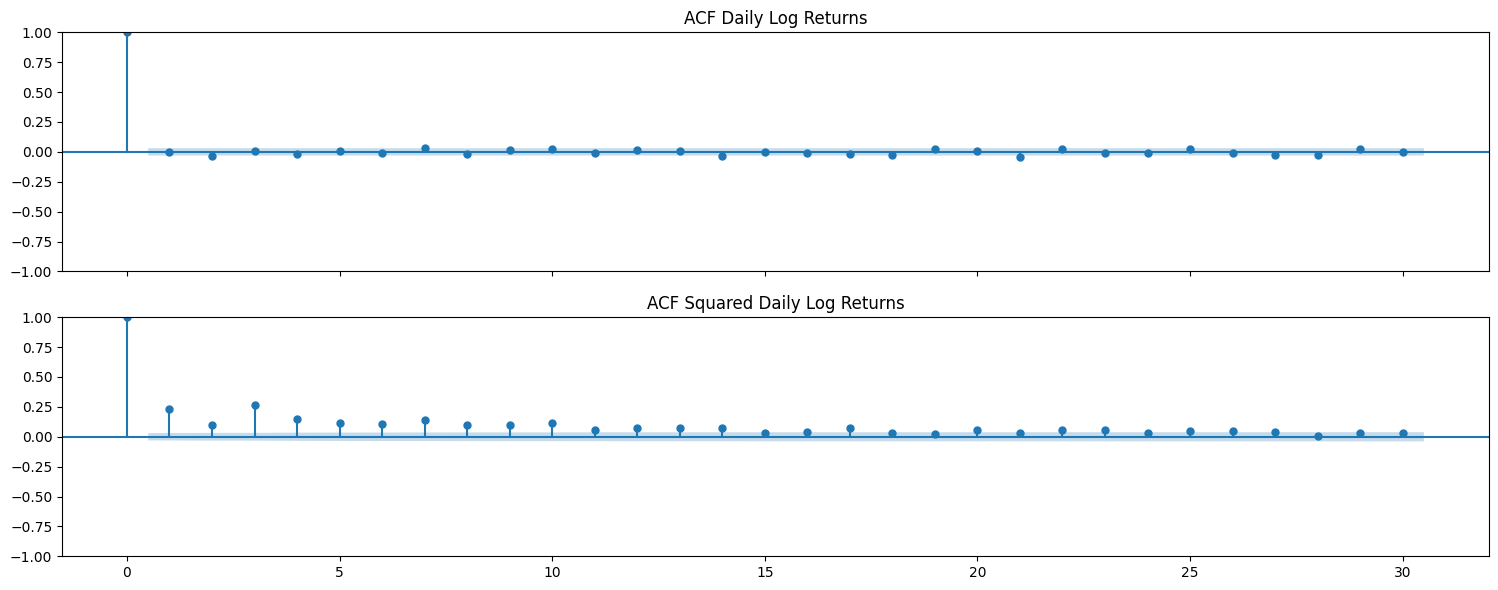

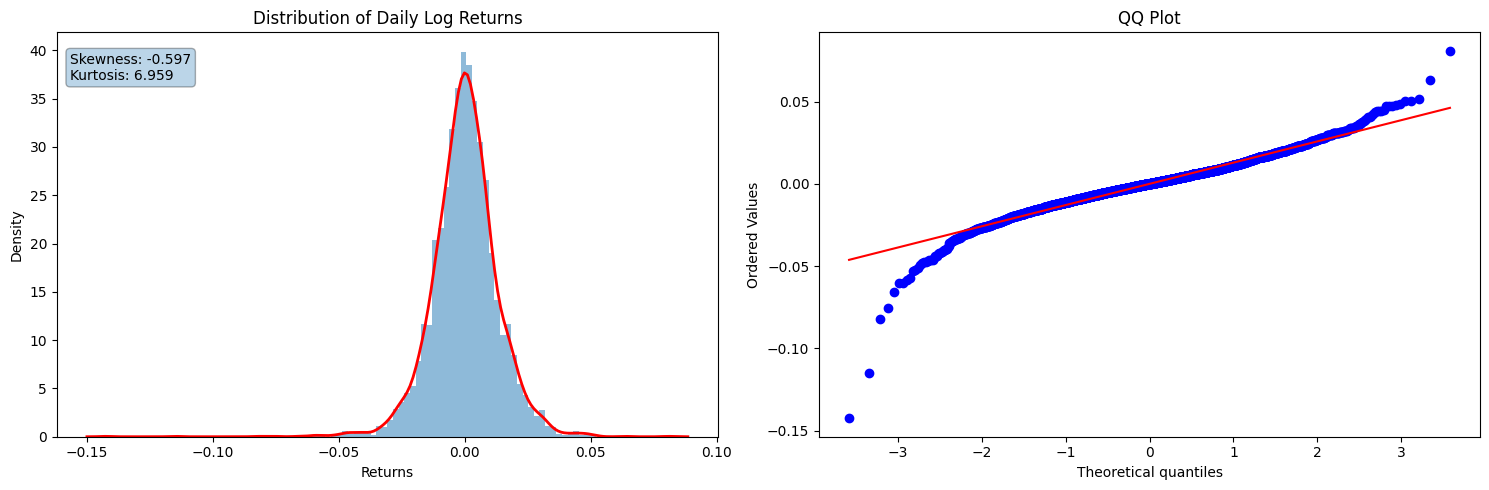

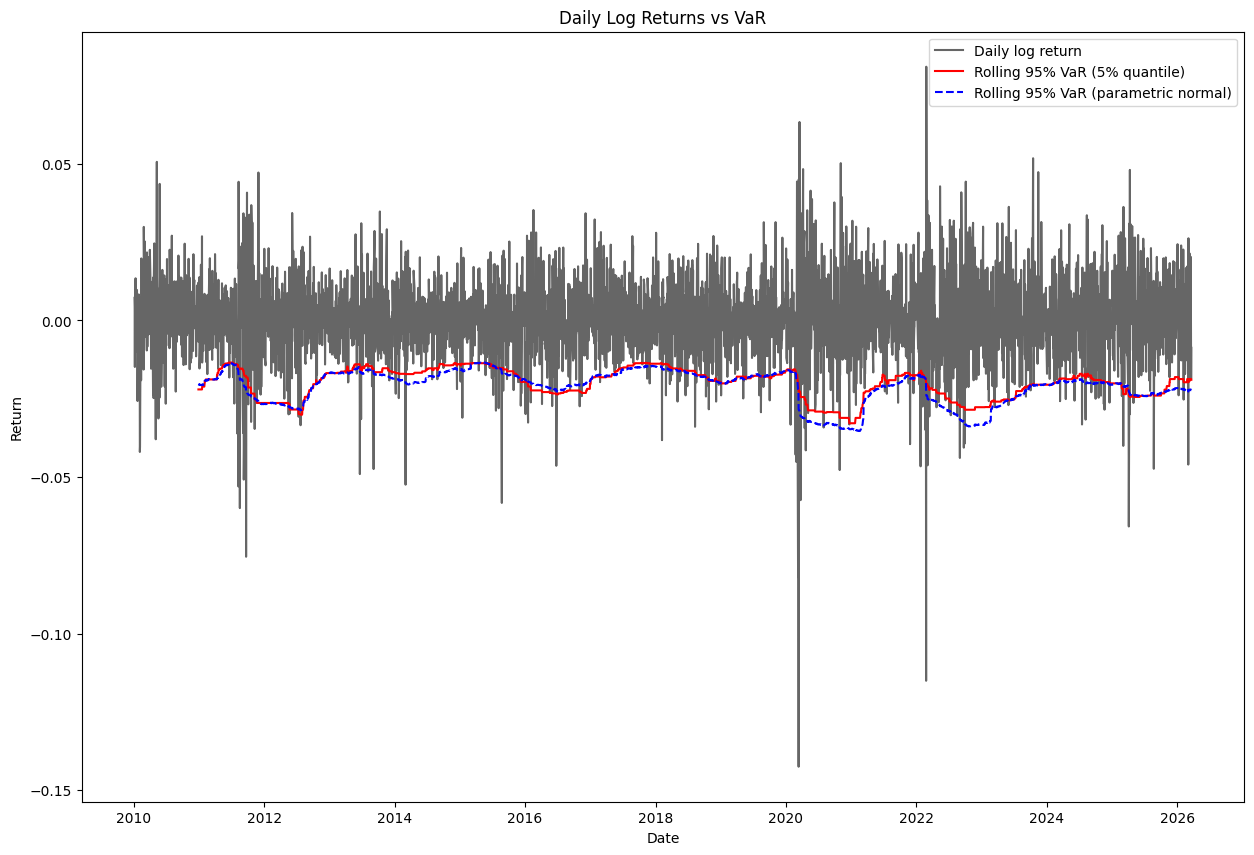

In [5]:
explore()